# ResNet-18 Phase 3: Joint Training with Pretrained Weights (100k images)

## Key Difference from Phase 2 v3:
- **Pretrained Classifier**: Start with ImageNet pretrained weights (not random init)
- **Lower Learning Rates**: Fine-tuning requires smaller LRs than training from scratch
- **More Data**: 100k images (80k train / 20k val) to prevent overfitting

## Why This Should Work:
- Phase 2 v3 struggled because training ResNet-18 from scratch on 20k images is very hard
- Pretrained weights give the classifier a strong starting point
- More data prevents overfitting when both mask and classifier are trainable

## Setup:
First run: `python scripts/cache_imagenet_100k.py` to create the 100k cache

## Comparison:
| Phase | Classifier Init | Classifier Training | Mask | Data |
|-------|-----------------|---------------------|------|------|
| Phase 1 | Pretrained | Frozen | Learnable | 25k |
| Phase 2 v3 | Random | Trainable | Learnable (normalized) | 25k |
| **Phase 3** | **Pretrained** | **Trainable (fine-tune)** | **Learnable (normalized)** | **100k** |

---

## 1. Setup and Imports

In [ ]:
import sys
import os

# Find project root by locating the 'frequency' module directory
_here = os.path.abspath('.')
for _candidate in [_here, os.path.join(_here, '..'), os.path.join(_here, '../..')]:
    _abs = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_abs, 'frequency')):
        if _abs not in sys.path:
            sys.path.insert(0, _abs)
        PROJECT_ROOT = _abs
        break

print(f"Project root: {PROJECT_ROOT}")

In [ ]:
import sys
import os

# Ensure project root is on sys.path regardless of which cell ran first
_here = os.path.abspath('.')
for _candidate in [_here, os.path.join(_here, '..'), os.path.join(_here, '../..')]:
    _abs = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_abs, 'frequency')):
        if _abs not in sys.path:
            sys.path.insert(0, _abs)
        PROJECT_ROOT = _abs
        break

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pathlib import Path
import time

from frequency.transforms import apply_fft, apply_ifft
from frequency.mask import Learnable2DFrequencyMask

print("Imports successful")
print(f"Project root: {PROJECT_ROOT}")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce GTX 1080 Ti
Memory: 11.70 GB


## 2. Load Dataset with Train/Val Split and Augmentation

In [4]:
from datasets import load_from_disk
from torchvision import transforms
from data.dataset import HFImageNetDataset

# Use 100k cache for more training data
CACHE_PATH = os.path.join(PROJECT_ROOT, "data", "imagenet_100k_cache")
BATCH_SIZE = 64
TRAIN_SPLIT = 0.8

# Check if cache exists
if not os.path.exists(CACHE_PATH):
    print(f"ERROR: Cache not found at {CACHE_PATH}")
    print("Please run: python scripts/cache_imagenet_100k.py")
    raise FileNotFoundError(f"Cache not found: {CACHE_PATH}")

print(f"Loading dataset from {CACHE_PATH}...")
imagenet_subset = load_from_disk(CACHE_PATH)
print(f"Loaded {len(imagenet_subset):,} images")

# Training transforms WITH augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transforms WITHOUT augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create full dataset (we'll apply transforms per-split)
full_dataset = HFImageNetDataset(imagenet_subset, transform=None)

# Split into train and validation
train_size = int(TRAIN_SPLIT * len(full_dataset))
val_size = len(full_dataset) - train_size

# Use generator for reproducibility
generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(range(len(full_dataset)), [train_size, val_size], generator=generator)

print(f"Train: {len(train_indices):,} | Val: {len(val_indices):,}")

Loading dataset from /home/bab61wot/VIT/SIM2REAL/data/imagenet_100k_cache...


Loading dataset from disk:   0%|          | 0/17 [00:00<?, ?it/s]

Loaded 100,000 images
Train: 80,000 | Val: 20,000


In [6]:
# Custom dataset wrapper to apply different transforms
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, indices, transform):
        self.hf_dataset = hf_dataset
        self.indices = list(indices)
        self.transform = transform
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        item = self.hf_dataset[real_idx]
        image = item['image']
        label = item['label']
        
        if image.mode != 'RGB':
            image = image.convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

train_dataset = TransformSubset(imagenet_subset, train_indices.indices, train_transform)
val_dataset = TransformSubset(imagenet_subset, val_indices.indices, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")

Train loader: 1250 batches
Val loader: 313 batches


## 3. Create Joint Training Pipeline with PRETRAINED Classifier

In [7]:
class JointTrainingPipeline(nn.Module):
    """
    Phase 3 Pipeline: Pretrained classifier + normalized mask.
    Both are trainable, but classifier uses lower LR for fine-tuning.
    """
    
    def __init__(self, classifier, image_size=224):
        super().__init__()
        
        self.classifier = classifier
        for param in self.classifier.parameters():
            param.requires_grad = True
        
        # Normalized mask (prevents collapse)
        self.freq_mask = Learnable2DFrequencyMask(
            image_size=image_size,
            init_value=1.0,
            init_std=0.1,
            normalize=True
        )
        
        mask_params = sum(p.numel() for p in self.freq_mask.parameters())
        classifier_params = sum(p.numel() for p in self.classifier.parameters())
        
        print(f"\nJointTrainingPipeline created:")
        print(f"  Frequency mask: {mask_params:,} trainable params (NORMALIZED)")
        print(f"  Classifier: {classifier_params:,} trainable params (PRETRAINED)")
    
    def forward(self, images):
        fft_result = apply_fft(images)
        masked_fft = self.freq_mask(fft_result)
        reconstructed = apply_ifft(masked_fft)
        outputs = self.classifier(reconstructed)
        return outputs, reconstructed
    
    def get_mask_params(self):
        return self.freq_mask.parameters()
    
    def get_classifier_params(self):
        return self.classifier.parameters()
    
    def get_mask_visualization(self):
        return self.freq_mask.get_mask_visualization()
    
    def get_raw_mask_stats(self):
        """Get stats of raw (unnormalized) mask weights for debugging"""
        raw = self.freq_mask.mask_weights.detach()
        return {'mean': raw.mean().item(), 'std': raw.std().item(), 
                'min': raw.min().item(), 'max': raw.max().item()}

In [8]:
# KEY CHANGE: Load PRETRAINED weights
print("Loading ResNet-18 with PRETRAINED ImageNet weights...")
classifier = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
print(f"  Parameters: {sum(p.numel() for p in classifier.parameters()):,}")

pipeline = JointTrainingPipeline(classifier, image_size=224)
pipeline = pipeline.to(device)
print(f"\nPipeline on {device}")

Loading ResNet-18 with PRETRAINED ImageNet weights...
  Parameters: 11,689,512

JointTrainingPipeline created:
  Frequency mask: 50,176 trainable params (NORMALIZED)
  Classifier: 11,689,512 trainable params (PRETRAINED)

Pipeline on cuda


## 4. Evaluate Baseline (Before Any Training)

In [10]:
def evaluate(pipeline, dataloader, criterion, device):
    """Evaluate on validation set"""
    pipeline.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs, _ = pipeline(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(dataloader), 100.0 * correct / total

criterion = nn.CrossEntropyLoss()

print("Evaluating baseline (pretrained weights, mask=1.0)...")
baseline_loss, baseline_acc = evaluate(pipeline, val_loader, criterion, device)
print(f"\nBaseline Validation Accuracy: {baseline_acc:.2f}%")
print(f"Baseline Validation Loss: {baseline_loss:.4f}")
print("\nThis should be similar to Phase 1 baseline (~65-67%)")

Evaluating baseline (pretrained weights, mask=1.0)...

Baseline Validation Accuracy: 73.81%
Baseline Validation Loss: 1.0209

This should be similar to Phase 1 baseline (~65-67%)


## 5. Training Configuration (Fine-tuning LRs)

In [11]:
# Hyperparameters - LOWER LRs for fine-tuning pretrained model
EPOCHS = 50
MASK_LR = 0.005          # Lower than v3 (was 0.01)
CLASSIFIER_LR = 0.0001   # Much lower - fine-tuning (was 0.001)
WEIGHT_DECAY = 0.0001
LR_STEP = 20
LR_GAMMA = 0.1
EARLY_STOP_PATIENCE = 10

optimizer = optim.Adam([
    {'params': pipeline.get_mask_params(), 'lr': MASK_LR},
    {'params': pipeline.get_classifier_params(), 'lr': CLASSIFIER_LR}
], weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

print("Training Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Mask LR: {MASK_LR} (learning frequency preferences)")
print(f"  Classifier LR: {CLASSIFIER_LR} (fine-tuning pretrained)")
print(f"  Mask normalization: ENABLED")
print(f"  Early stopping patience: {EARLY_STOP_PATIENCE}")

Training Configuration:
  Epochs: 50
  Batch size: 64
  Mask LR: 0.005 (learning frequency preferences)
  Classifier LR: 0.0001 (fine-tuning pretrained)
  Mask normalization: ENABLED
  Early stopping patience: 10


In [12]:
RESULTS_DIR = Path(PROJECT_ROOT) / "experiments" / "results" / "resnet18_phase3.1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results: {RESULTS_DIR}")

Results: /home/bab61wot/VIT/SIM2REAL/experiments/results/resnet18_phase3.1


## 6. Training Loop

In [13]:
# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'mask_std': []
}
best_val_acc = baseline_acc  # Start from baseline
patience_counter = 0
start_epoch = 0

# Check for checkpoint
checkpoint_path = RESULTS_DIR / "checkpoint.pt"
if checkpoint_path.exists():
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    pipeline.load_state_dict(checkpoint['pipeline_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch']
    best_val_acc = checkpoint['best_val_acc']
    patience_counter = checkpoint.get('patience_counter', 0)
    history = checkpoint['history']
    print(f"Resumed from epoch {start_epoch}, best_val_acc={best_val_acc:.2f}%")
else:
    print("Starting fresh training")
    print(f"Baseline to beat: {baseline_acc:.2f}%")

print(f"\nTraining for {EPOCHS} epochs (from {start_epoch})...")
print("=" * 70)

Starting fresh training
Baseline to beat: 73.81%

Training for 50 epochs (from 0)...


Epoch 1/50: 100%|████████████████████████████████████████████████████████████████████████████████| 1250/1250 [08:09<00:00,  2.55it/s, loss=1.276, acc=69.1%]



Epoch 1/50 (557.1s)
  Train: Loss=1.2144, Acc=69.06%
  Val:   Loss=1.2929, Acc=67.14%
  Mask (normalized): mean=1.000, std=1.008
  Gap:   1.92% (train - val)
  vs Baseline: -6.66%
  No improvement (1/10)
----------------------------------------------------------------------


Epoch 2/50: 100%|████████████████████████████████████████████████████████████████████████████████| 1250/1250 [08:05<00:00,  2.58it/s, loss=1.039, acc=75.2%]



Epoch 2/50 (553.4s)
  Train: Loss=0.9649, Acc=75.17%
  Val:   Loss=1.3334, Acc=66.75%
  Mask (normalized): mean=1.000, std=1.121
  Gap:   8.41% (train - val)
  vs Baseline: -7.05%
  No improvement (2/10)
----------------------------------------------------------------------


Epoch 3/50: 100%|████████████████████████████████████████████████████████████████████████████████| 1250/1250 [08:06<00:00,  2.57it/s, loss=0.990, acc=79.7%]


...


Epoch 8/50 (552.8s)
  Train: Loss=0.3726, Acc=91.56%
  Val:   Loss=1.6038, Acc=61.28%
  Mask (normalized): mean=1.000, std=1.131
  Gap:   30.28% (train - val)
  vs Baseline: -12.53%
  No improvement (8/10)
----------------------------------------------------------------------


Epoch 9/50: 100%|████████████████████████████████████████████████████████████████████████████████| 1250/1250 [08:05<00:00,  2.57it/s, loss=0.396, acc=93.0%]



Epoch 9/50 (553.2s)
  Train: Loss=0.3269, Acc=92.97%
  Val:   Loss=1.6254, Acc=61.70%
  Mask (normalized): mean=1.000, std=1.141
  Gap:   31.26% (train - val)
  vs Baseline: -12.10%
  No improvement (9/10)
----------------------------------------------------------------------


Epoch 10/50: 100%|███████████████████████████████████████████████████████████████████████████████| 1250/1250 [08:05<00:00,  2.57it/s, loss=0.319, acc=94.0%]



Epoch 10/50 (553.2s)
  Train: Loss=0.2923, Acc=93.95%
  Val:   Loss=1.6849, Acc=60.70%
  Mask (normalized): mean=1.000, std=1.146
  Gap:   33.25% (train - val)
  vs Baseline: -13.11%
  No improvement (10/10)


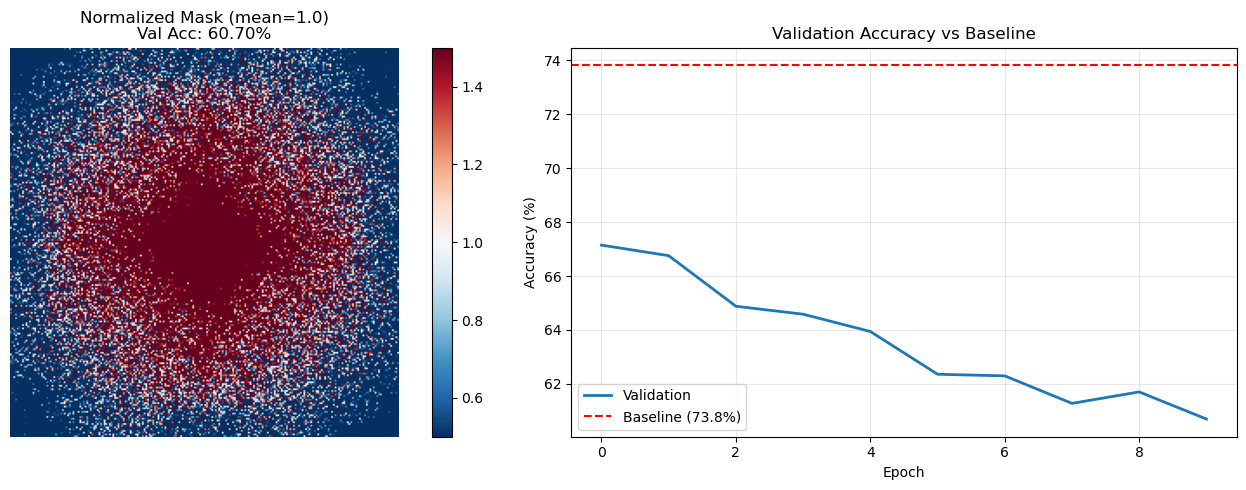


Early stopping at epoch 10!

TRAINING COMPLETE!
Baseline Accuracy: 73.81%
Best Validation Accuracy: 73.81%
Improvement: +0.00%


In [14]:
# Main training loop
for epoch in range(start_epoch, EPOCHS):
    epoch_start = time.time()
    pipeline.train()
    
    train_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs, _ = pipeline(images)
        
        # Only classification loss
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if batch_idx % 20 == 0:
            pbar.set_postfix({'loss': f"{loss.item():.3f}", 'acc': f"{100.*correct/total:.1f}%"})
    
    scheduler.step()
    
    # Validation
    val_loss, val_acc = evaluate(pipeline, val_loader, criterion, device)
    
    # Epoch stats
    train_loss /= len(train_loader)
    train_acc = 100.0 * correct / total
    epoch_time = time.time() - epoch_start
    
    # Get mask stats
    mask_viz = pipeline.get_mask_visualization()
    raw_stats = pipeline.get_raw_mask_stats()
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['mask_std'].append(mask_viz.std())
    
    print(f"\nEpoch {epoch+1}/{EPOCHS} ({epoch_time:.1f}s)")
    print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
    print(f"  Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
    print(f"  Mask (normalized): mean={mask_viz.mean():.3f}, std={mask_viz.std():.3f}")
    print(f"  Gap:   {train_acc - val_acc:.2f}% (train - val)")
    print(f"  vs Baseline: {val_acc - baseline_acc:+.2f}%")
    
    # Check for improvement
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        patience_counter = 0
        print(f"  ** New best validation accuracy: {best_val_acc:.2f}% **")
        torch.save({'pipeline_state_dict': pipeline.state_dict(), 'val_acc': val_acc},
                   RESULTS_DIR / "best_model.pt")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{EARLY_STOP_PATIENCE})")
    
    # Save checkpoint
    torch.save({
        'epoch': epoch + 1,
        'pipeline_state_dict': pipeline.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc,
        'patience_counter': patience_counter,
        'history': history,
        'baseline_acc': baseline_acc
    }, checkpoint_path)
    
    # Visualize mask every 10 epochs
    if (epoch + 1) % 10 == 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        im0 = axes[0].imshow(mask_viz, cmap='RdBu_r', vmin=0.5, vmax=1.5)
        axes[0].set_title(f'Normalized Mask (mean=1.0)\nVal Acc: {val_acc:.2f}%')
        axes[0].axis('off')
        plt.colorbar(im0, ax=axes[0])
        
        axes[1].plot(history['val_acc'], linewidth=2, label='Validation')
        axes[1].axhline(y=baseline_acc, color='red', linestyle='--', label=f'Baseline ({baseline_acc:.1f}%)')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].set_title('Validation Accuracy vs Baseline')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"mask_epoch_{epoch+1}.png", dpi=150, bbox_inches='tight')
        plt.show()
    
    # Early stopping
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}!")
        break
    
    print("-" * 70)

print("\n" + "=" * 70)
print("TRAINING COMPLETE!")
print(f"Baseline Accuracy: {baseline_acc:.2f}%")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Improvement: {best_val_acc - baseline_acc:+.2f}%")
print("=" * 70)

## 7. Training History

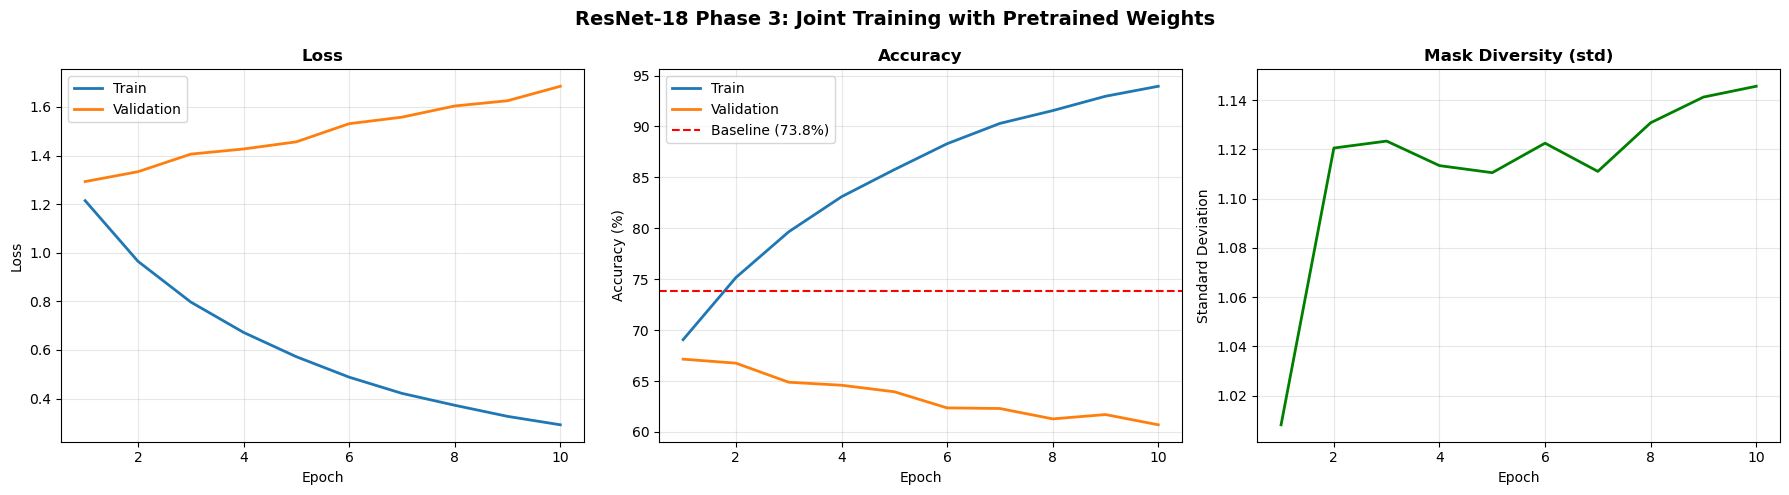


Final Stats:
  Baseline:  73.81%
  Train Acc: 93.95%
  Val Acc:   60.70%
  Best Val:  73.81%
  Improvement: +0.00%


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], label='Validation', linewidth=2)
axes[1].axhline(y=baseline_acc, color='red', linestyle='--', label=f'Baseline ({baseline_acc:.1f}%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Mask std
axes[2].plot(epochs_range, history['mask_std'], linewidth=2, color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Standard Deviation')
axes[2].set_title('Mask Diversity (std)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('ResNet-18 Phase 3: Joint Training with Pretrained Weights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_history.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Stats:")
print(f"  Baseline:  {baseline_acc:.2f}%")
print(f"  Train Acc: {history['train_acc'][-1]:.2f}%")
print(f"  Val Acc:   {history['val_acc'][-1]:.2f}%")
print(f"  Best Val:  {best_val_acc:.2f}%")
print(f"  Improvement: {best_val_acc - baseline_acc:+.2f}%")

## 8. Load Best Model and Visualize Mask

In [16]:
# Load best model
best_checkpoint = torch.load(RESULTS_DIR / "best_model.pt", map_location=device, weights_only=False)
pipeline.load_state_dict(best_checkpoint['pipeline_state_dict'])
print(f"Loaded best model (Val Acc: {best_checkpoint['val_acc']:.2f}%)")

learned_mask = pipeline.get_mask_visualization()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(learned_mask, cmap='RdBu_r', vmin=0.5, vmax=1.5)
ax.set_title(f'Phase 3 Learned Mask\n(Val Acc: {best_checkpoint["val_acc"]:.2f}%, Baseline: {baseline_acc:.2f}%)', fontweight='bold', fontsize=14)
ax.axis('off')
plt.colorbar(im, ax=ax, label='Mask Weight')
plt.savefig(RESULTS_DIR / "learned_mask.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNormalized Mask Statistics:")
print(f"  Min:  {learned_mask.min():.4f}")
print(f"  Max:  {learned_mask.max():.4f}")
print(f"  Mean: {learned_mask.mean():.4f} (should be ~1.0)")
print(f"  Std:  {learned_mask.std():.4f}")

FileNotFoundError: [Errno 2] No such file or directory: '/home/bab61wot/VIT/SIM2REAL/experiments/results/resnet18_phase3.1/best_model.pt'

## 9. Compare with Phase 1

In [16]:
phase1_dir = Path(PROJECT_ROOT) / "experiments" / "results" / "resnet18"
phase1_mask_path = phase1_dir / "learned_mask.pt"

if phase1_mask_path.exists():
    # Load Phase 1 mask
    phase1_mask_module = Learnable2DFrequencyMask(image_size=224, normalize=False)
    phase1_mask_module.load_state_dict(torch.load(phase1_mask_path, map_location='cpu', weights_only=False))
    phase1_mask = phase1_mask_module.get_mask_visualization()
    phase3_mask = learned_mask
    
    # Radial profile function
    def radial_profile(mask):
        h, w = mask.shape
        cy, cx = h // 2, w // 2
        y, x = np.ogrid[:h, :w]
        r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
        r_max = int(np.sqrt(cx ** 2 + cy ** 2))
        profile = []
        for rad in range(r_max):
            ring = (r >= rad) & (r < rad + 1)
            if ring.sum() > 0:
                profile.append(mask[ring].mean())
        return profile
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    im0 = axes[0].imshow(phase1_mask, cmap='RdBu_r', vmin=0.5, vmax=1.5)
    axes[0].set_title('Phase 1\n(Pretrained, frozen classifier)', fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(phase3_mask, cmap='RdBu_r', vmin=0.5, vmax=1.5)
    axes[1].set_title('Phase 3\n(Pretrained, fine-tuned classifier)', fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1])
    
    diff = phase3_mask - phase1_mask
    vmax = max(abs(diff.min()), abs(diff.max()))
    im2 = axes[2].imshow(diff, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    axes[2].set_title('Difference (P3 - P1)', fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])
    
    axes[3].plot(radial_profile(phase1_mask), label='Phase 1', linewidth=2)
    axes[3].plot(radial_profile(phase3_mask), label='Phase 3', linewidth=2)
    axes[3].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    axes[3].set_xlabel('Frequency (0=DC, higher=high freq)')
    axes[3].set_ylabel('Mask Weight')
    axes[3].set_title('Radial Profiles', fontweight='bold')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    plt.suptitle('ResNet-18: Phase 1 vs Phase 3', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "phase1_vs_phase3.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Correlation
    correlation = np.corrcoef(phase1_mask.flatten(), phase3_mask.flatten())[0, 1]
    print(f"\n=== Phase 1 vs Phase 3 Analysis ===")
    print(f"Mask correlation: {correlation:.4f}")
    print()
    if correlation > 0.7:
        print("HIGH correlation -> Frequency preference is ARCHITECTURAL")
        print("  The mask learns similar patterns whether classifier is frozen or fine-tuned")
    elif correlation > 0.4:
        print("MODERATE correlation -> Mix of architectural and learned preferences")
    else:
        print("LOW correlation -> Frequency preference changes with classifier training")
else:
    print("Phase 1 results not found")

NameError: name 'learned_mask' is not defined

## 10. Save Results

In [ ]:
torch.save(pipeline.freq_mask.state_dict(), RESULTS_DIR / "learned_mask.pt")
torch.save(history, RESULTS_DIR / "training_history.pt")

with open(RESULTS_DIR / "summary.txt", 'w') as f:
    f.write("ResNet-18 Phase 3 - Joint Training with Pretrained Weights\n")
    f.write("=" * 55 + "\n\n")
    f.write(f"Architecture: ResNet-18 (ImageNet pretrained)\n")
    f.write(f"Train samples: {len(train_dataset):,}\n")
    f.write(f"Val samples: {len(val_dataset):,}\n")
    f.write(f"Epochs trained: {len(history['train_acc'])}\n")
    f.write(f"\nResults:\n")
    f.write(f"  Baseline Accuracy: {baseline_acc:.2f}%\n")
    f.write(f"  Best Val Accuracy: {best_val_acc:.2f}%\n")
    f.write(f"  Improvement: {best_val_acc - baseline_acc:+.2f}%\n")
    f.write(f"\nKey Difference from Phase 2 v3:\n")
    f.write(f"  Classifier: PRETRAINED (not random init)\n")
    f.write(f"  Classifier LR: {CLASSIFIER_LR} (fine-tuning)\n")
    f.write(f"\nHyperparameters:\n")
    f.write(f"  Mask LR: {MASK_LR}\n")
    f.write(f"  Classifier LR: {CLASSIFIER_LR}\n")
    f.write(f"  Data augmentation: Yes\n")

print("Results saved!")
print(f"  {RESULTS_DIR}")

## 11. Summary

In [ ]:
print("=" * 70)
print("RESNET-18 PHASE 4 SUMMARY")
print("=" * 70)
print(f"\nKey Change: Pretrained classifier weights (not random init)")
print(f"  - Classifier already knows ImageNet features")
print(f"  - Mask can focus on learning frequency preferences")
print(f"  - Fine-tuning with low LR preserves pretrained knowledge")
print(f"\nTraining Setup:")
print(f"  Train/Val Split: {len(train_dataset):,} / {len(val_dataset):,}")
print(f"  Data Augmentation: RandomResizedCrop, HorizontalFlip, ColorJitter")
print(f"  Mask LR: {MASK_LR}, Classifier LR: {CLASSIFIER_LR}")
print(f"\nResults:")
print(f"  Baseline Accuracy: {baseline_acc:.2f}%")
print(f"  Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"  Improvement: {best_val_acc - baseline_acc:+.2f}%")
print(f"\nInterpretation:")
if best_val_acc > baseline_acc:
    print(f"  The mask improved accuracy -> frequency filtering helps!")
else:
    print(f"  The mask did not improve accuracy -> classifier adaptation dominated")
print(f"\nArtifacts: {RESULTS_DIR}")
print(f"\nNext: Compare Phase 3 mask with Phase 1 to see if fine-tuning changes frequency preferences")